# Imports:

In [1]:
import tensorflow as tf
from tensorflow import keras

physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

if physical_devices:
    for gpu in physical_devices:
        print("Device Details:", gpu)
        
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("Warning: TensorFlow is using the CPU.")

Num GPUs Available:  1
Device Details: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
import pandas as pd
import json
from torchvision import transforms
import uuid
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from model_utils import *

In [3]:
# path for the new images
base_path = "./data" 
aug_dir = os.path.join(base_path, "HAM10000_augmented")
if not os.path.exists(aug_dir):
    os.makedirs(aug_dir)

In [4]:
# 1. Load the CSVs without 'dx_encoded' (since it's not in the file)
train_df = pd.read_csv('data/train_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
val_df = pd.read_csv('data/val_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path', 'dx']]
test_df = pd.read_csv('data/test_split.csv')[['image_id', 'dataset', 'lesion_id','cleaned_path','dx']]

# 2. Load your mapping dictionary
with open("label2idx.json", "r") as f:
    label2idx = json.load(f)

# 3. Re-create the encoded column using the loaded dictionary
train_df["dx_encoded"] = train_df["dx"].map(label2idx)
val_df["dx_encoded"] = val_df["dx"].map(label2idx)
test_df["dx_encoded"] = test_df["dx"].map(label2idx)

In [5]:
train_df

,image_id,dataset,lesion_id,cleaned_path,dx,dx_encoded
0,ISIC_0028291,vidir_modern,HAM_0006253,./data\HAM10000_cleaned\ISIC_0028291_cleaned.jpg,mel,4
1,ISIC_0028308,rosendahl,HAM_0003752,./data\HAM10000_cleaned\ISIC_0028308_cleaned.jpg,bkl,2
2,ISIC_0028286,vidir_molemax,HAM_0005470,./data\HAM10000_cleaned\ISIC_0028286_cleaned.jpg,nv,5
3,ISIC_0028300,vidir_molemax,HAM_0004092,./data\HAM10000_cleaned\ISIC_0028300_cleaned.jpg,nv,5
4,ISIC_0028292,vidir_molemax,HAM_0006686,./data\HAM10000_cleaned\ISIC_0028292_cleaned.jpg,nv,5
...,...,...,...,...,...,...
7986,ISIC_0029315,rosendahl,HAM_0004780,./data\HAM10000_cleaned\ISIC_0029315_cleaned.jpg,akiec,0
7987,ISIC_0029334,vienna_dias,HAM_0002881,./data\HAM10000_cleaned\ISIC_0029334_cleaned.jpg,nv,5
7988,ISIC_0029335,vidir_molemax,HAM_0005119,./data\HAM10000_cleaned\ISIC_0029335_cleaned.jpg,nv,5
7989,ISIC_0029324,vidir_molemax,HAM_0007380,./data\HAM10000_cleaned\ISIC_0029324_cleaned.jpg,nv,5


In [6]:
train_df = train_df.rename(columns={'cleaned_path': 'image_path'})
val_df = val_df.rename(columns={'cleaned_path': 'image_path'})
test_df = test_df.rename(columns={'cleaned_path': 'image_path'})

train_df['dataset'] = 'original'
val_df['dataset'] = 'original'
test_df['dataset'] = 'original'

with open("label2idx.json", "r") as f:
    label2idx = json.load(f)

In [7]:
train_df.head()

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
0,ISIC_0028291,original,HAM_0006253,./data\HAM10000_cleaned\ISIC_0028291_cleaned.jpg,mel,4
1,ISIC_0028308,original,HAM_0003752,./data\HAM10000_cleaned\ISIC_0028308_cleaned.jpg,bkl,2
2,ISIC_0028286,original,HAM_0005470,./data\HAM10000_cleaned\ISIC_0028286_cleaned.jpg,nv,5
3,ISIC_0028300,original,HAM_0004092,./data\HAM10000_cleaned\ISIC_0028300_cleaned.jpg,nv,5
4,ISIC_0028292,original,HAM_0006686,./data\HAM10000_cleaned\ISIC_0028292_cleaned.jpg,nv,5


# Data Augmentation

## Strategies per Class

In [8]:
# ImageNet Transfer Learning RGB Weights
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

In [9]:
# PYTORCH?

# ── STRATEGY 1 — Light (geometric only) ──────────────────────────────────────
# Safe flips and rotation, nothing that touches color or structure
strategy_1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Save version without ToTensor and Normalize
save_strategy_1 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
])

# ── STRATEGY 2 — Moderate (geometry + mild color) ─────────────────────────────
# Adds subtle brightness/contrast to simulate lighting variation
strategy_2 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.05)),  # simulates hair/occlusion
])

# Save version without ToTensor and Normalize
save_strategy_2 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

# ── STRATEGY 3 — Aggressive (everything + elastic + perspective) ────────────
# Most aggressive — use only for extreme minority classes (vasc, df)
strategy_3 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.15, hue=0.05),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ElasticTransform(alpha=40.0, sigma=4.0),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.35, scale=(0.02, 0.08)),
])

# Save version without ToTensor and Normalize
save_strategy_3 = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.15, hue=0.05),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.75, 1.0)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ElasticTransform(alpha=40.0, sigma=4.0),
])

# Base strategy, for the majority class
strat_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

save_strat_base = transforms.Compose([]) #no transformations for base when saving

In [10]:
strategy_map = {
    "nv":    strat_base,
    "mel":   strategy_1,
    "bkl":   strategy_1,
    "bcc":   strategy_2,
    "akiec": strategy_2,
    "vasc":  strategy_3,
    "df":    strategy_3,
}

save_strategy_map = {
    "nv":    save_strat_base,
    "mel":   save_strategy_1,
    "bkl":   save_strategy_1,
    "bcc":   save_strategy_2,
    "akiec": save_strategy_2,
    "vasc":  save_strategy_3,
    "df":    save_strategy_3,
}

augmentation_multiplier_map = {
    "nv":    1,
    "mel":   3,
    "bkl":   3,
    "bcc":   4,
    "akiec": 5,
    "vasc":  8,
    "df":    8,
}

# alterar consoante código de resize do Graça
resize = transforms.Resize((224, 224))

## Augmentation Pipeline

Organizar em pipeline?

In [11]:
def apply_augmentation(image_path, label):
    with Image.open(image_path) as img:
        img = resize(img.convert("RGB"))
        return strategy_map[label](img)

In [12]:
def offline_augmentation(df, label, multiplier):
    new_rows = []
    class_df = df[df['dx'] == label]
    paths = class_df['image_path'].tolist()

    n_to_generate = len(paths) * (multiplier - 1)

    for i in range(int(n_to_generate)):
        original_path = paths[i % len(paths)]
        original_row = class_df.iloc[i % len(class_df)] # Get the full row for metadata

        img = Image.open(original_path).convert('RGB')
        img = resize(img) # Apply resize

        transform = save_strategy_map.get(label) # Use save_strategy_map
        if transform:
            img = transform(img)

        new_id = f"AUG_{label}_{uuid.uuid4().hex[:8]}"
        new_filename = f"{new_id}.jpg"
        save_path = os.path.join(aug_dir, new_filename)
        img.save(save_path, "JPEG", quality=95)

        new_row_dict = {
            'image_id': new_id,
            'image_path': save_path,
            'dx': label,
            'dataset': 'augmented' # Mark as augmented
        }
        # Copy other metadata from the original row, but generate new lesion_id
        for col in ['dx_type', 'age', 'sex', 'localization']:
            if col in original_row:
                new_row_dict[col] = original_row[col]
        new_row_dict['lesion_id'] = f"AUG_LESION_{label}_{uuid.uuid4().hex[:8]}" # Always generate new lesion_id

        new_rows.append(new_row_dict)
    return new_rows

In [13]:
# 6 MIN
# generate augmented images and collect metadata
all_new_metadata = []
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor: # Use all available CPU cores
    futures = []
    for label, multiplier in augmentation_multiplier_map.items():
        if multiplier > 1:
            print(f"Submitting task for augmenting {label} (multiplier: {multiplier})")
            # pass the original train_df to the function
            futures.append(executor.submit(offline_augmentation, train_df, label, multiplier))

    for future in tqdm(futures, desc="Generating all augmented images"): # Use tqdm on futures list
        all_new_metadata.extend(future.result())

augmented_df = pd.DataFrame(all_new_metadata)

# handle undersampling of 'nv' from the original train_df
nv_original_df = train_df[train_df["dx"] == "nv"]
nv_undersampled_df = nv_original_df.sample(n=4500, random_state=42)

# exclude original 'nv' from train_df and add the undersampled version
non_nv_original_df = train_df[train_df["dx"] != "nv"]
processed_original_df = pd.concat([non_nv_original_df, nv_undersampled_df], ignore_index=True)

# combine processed original with augmented
aug_train_df = pd.concat([processed_original_df, augmented_df], ignore_index=True)

# save  new CSV
aug_train_df.to_csv(os.path.join(base_path, "augmented_metadata.csv"), index=False)

print("\nFinal distribution after offline augmentation and undersampling:")
print(aug_train_df["dx"].value_counts())

Submitting task for augmenting mel (multiplier: 3)
Submitting task for augmenting bkl (multiplier: 3)
Submitting task for augmenting bcc (multiplier: 4)
Submitting task for augmenting akiec (multiplier: 5)
Submitting task for augmenting vasc (multiplier: 8)
Submitting task for augmenting df (multiplier: 8)


Generating all augmented images: 100%|██████████| 6/6 [00:51<00:00,  8.60s/it]


Final distribution after offline augmentation and undersampling:
dx
nv       4500
mel      2631
bkl      2568
bcc      1696
akiec    1300
vasc      864
df        776
Name: count, dtype: int64


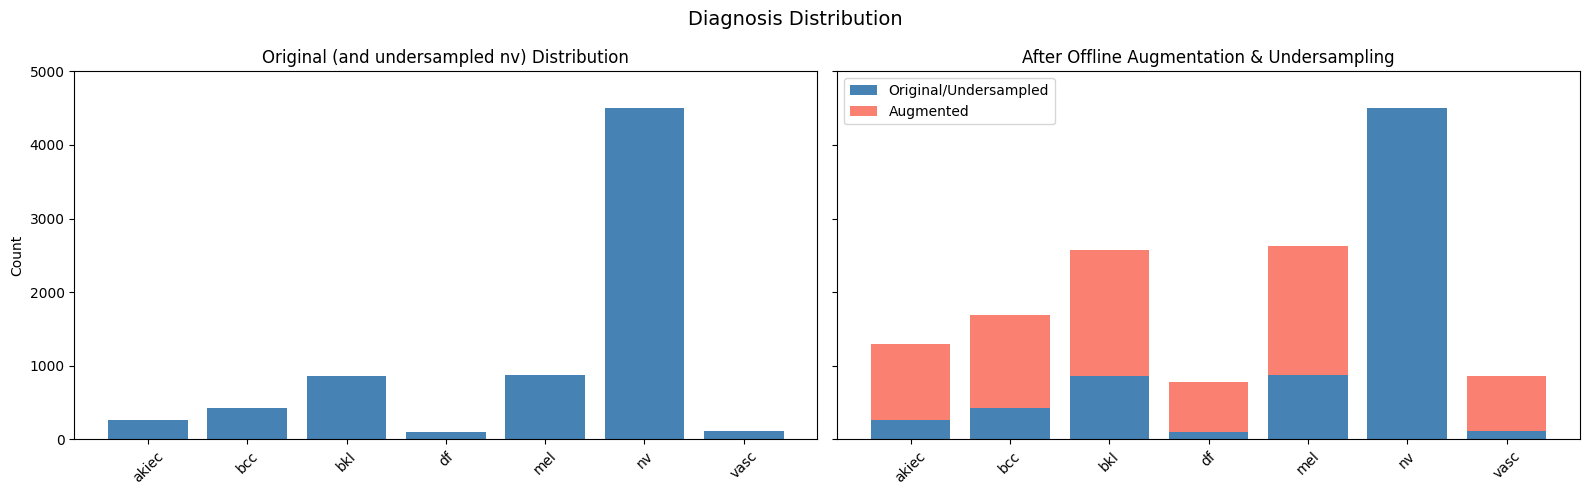

In [14]:
labels = sorted(aug_train_df["dx"].unique())

original_distribution_counts = [len(processed_original_df[processed_original_df["dx"] == l]) for l in labels]
augmented_counts_from_df = [len(augmented_df[augmented_df["dx"] == l]) for l in labels]

x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# ── Original
axes[0].bar(x, original_distribution_counts, color="steelblue")
axes[0].set_title("Original (and undersampled nv) Distribution")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_ylabel("Count")

# ── After undersampled nv + augmented others stacked
axes[1].bar(x, original_distribution_counts, color="steelblue", label="Original/Undersampled")
axes[1].bar(x, augmented_counts_from_df, bottom=original_distribution_counts, color="salmon", label="Augmented")
axes[1].set_title("After Offline Augmentation & Undersampling")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].legend()
axes[1].set_ylim(0, 5000)

plt.suptitle("Diagnosis Distribution", fontsize=14)
plt.tight_layout()
plt.show()

# Modelling

In [15]:
aug_train_df.sample(5)

,image_id,dataset,lesion_id,image_path,dx,dx_encoded
8789,AUG_mel_abd9fda1,augmented,AUG_LESION_mel_f237099d,./data\HAM10000_augmented\AUG_mel_abd9fda1.jpg,mel,NaN
4198,ISIC_0032501,original,HAM_0001467,./data\HAM10000_cleaned\ISIC_0032501_cleaned.jpg,nv,5.0
10436,AUG_bkl_8c7acbe1,augmented,AUG_LESION_bkl_c477d096,./data\HAM10000_augmented\AUG_bkl_8c7acbe1.jpg,bkl,NaN
10494,AUG_bkl_1f90665f,augmented,AUG_LESION_bkl_3e4c6c25,./data\HAM10000_augmented\AUG_bkl_1f90665f.jpg,bkl,NaN
1428,ISIC_0033908,original,HAM_0003978,./data\HAM10000_cleaned\ISIC_0033908_cleaned.jpg,bkl,2.0


In [16]:
# Class weights
classes = np.array(sorted(aug_train_df["dx"].unique()))

class_weights = compute_class_weight(class_weight="balanced",classes=classes,y=aug_train_df["dx"])
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

In [17]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # VERIFICAR PARA QUE É QUE ISTO SERVE
N_CLASSES  = len(label2idx) # VERIFICAR PARA QUE É QUE ISTO SERVE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

In [18]:
def make_dataset(df, shuffle=False, repeat=False):
    paths = df["image_path"].values
    labels = df["dx_encoded"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda x, y: load_image(x, y), num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    
    if repeat:
        ds = ds.repeat()  

    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

In [19]:
aug_train_df["dx_encoded"] = aug_train_df["dx"].map(label2idx)

aug_train_df["dx_encoded"] = aug_train_df["dx_encoded"].astype(int)
train_ds = make_dataset(aug_train_df, shuffle=True, repeat=True)  
val_ds   = make_dataset(val_df)                               
test_ds  = make_dataset(test_df)

In [20]:
model_baseline = keras.Sequential([
    keras.layers.Conv2D(8, kernel_size=6, activation="relu", input_shape=(224, 224, 3)),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(len(label2idx))
])

model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [21]:
epochs = 10
spe = 100

history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    steps_per_epoch=spe,
    class_weight=class_weights_dict
)

Epoch 1/10
100/100 [==============================] - 28s 48ms/step - loss: 1.9612 - accuracy: 0.1831 - val_loss: 1.9033 - val_accuracy: 0.4673
Epoch 2/10
100/100 [==============================] - 4s 40ms/step - loss: 1.9541 - accuracy: 0.2313 - val_loss: 1.8983 - val_accuracy: 0.3746
Epoch 3/10
100/100 [==============================] - 5s 48ms/step - loss: 1.9147 - accuracy: 0.2841 - val_loss: 1.8817 - val_accuracy: 0.4127
Epoch 4/10
100/100 [==============================] - 6s 62ms/step - loss: 1.9129 - accuracy: 0.3006 - val_loss: 1.8393 - val_accuracy: 0.4537
Epoch 5/10
100/100 [==============================] - 11s 112ms/step - loss: 1.9263 - accuracy: 0.3294 - val_loss: 1.8152 - val_accuracy: 0.4722
Epoch 6/10
100/100 [==============================] - 12s 117ms/step - loss: 1.8826 - accuracy: 0.3203 - val_loss: 1.7877 - val_accuracy: 0.4722
Epoch 7/10
100/100 [==============================] - 18s 179ms/step - loss: 1.9060 - accuracy: 0.3153 - val_loss: 1.7924 - val_accuracy:

Model A — Custom CNN with Keras Tuner <br>
Model B — EfficientNetB0 <br>
Model C — MobileNetV2 <br>

## EfficientNetB0

EfficientNetB0 was selected as the first pretrained architecture based on three
key criteria: parameter efficiency, proven medical imaging performance and
architectural design alignment with our task.

In [ ]:
UNFREEZE_FROM_B = -30   # unfreeze last 30 layers of EfficientNetB0

def build_efficientnet():
    base = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        pooling=None
        
    )
    base.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.4)(x)
    x = keras.layers.Dense(256, activation="relu")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(N_CLASSES)(x)
    return keras.Model(inputs, outputs, name="efficientnet_b0")

In [ ]:
STEPS_PER_EPOCH=20
# phase 1: head only
model_pt1 = build_efficientnet() # Model Pre-Trained 1
model_pt1.summary()

model_pt1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history1_pt1 = model_pt1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("checkpoints/model_b_phase1.weights.h5",
                            patience_es=6, patience_lr=3)
)

plot_history(history1_pt1, "Model B — EfficientNetB0 Phase 1 (head only)")

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Recreate your idx2label mapping (just in case it's not in memory)
idx2label = {idx: label for label, idx in label2idx.items()}
class_names = [idx2label[i] for i in range(len(idx2label))]

# 2. Extract the true labels directly from your validation dataset
# (This assumes val_ds is a tf.data.Dataset yielding (images, labels) tuples)
print("Extracting true labels...")
y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

# 3. Generate the model's predictions
print("Generating model predictions...")
y_pred_logits = model_pt1.predict(val_ds)

# 4. Convert raw logits into the predicted class index (0 through 6)
y_pred = np.argmax(y_pred_logits, axis=1)

# 5. Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 6. Plot it as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Phase 1 Confusion Matrix: The Majority Class Trap', pad=20, fontsize=14)
plt.xlabel('Predicted Label (What the model guessed)', fontsize=12)
plt.ylabel('True Label (Actual diagnosis)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras

class SparseFocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.0, from_logits=True, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        # 1. Calculate the standard Cross-Entropy loss
        ce_loss = keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=self.from_logits
        )
        
        # 2. Get the probabilities (converting from logits if necessary)
        if self.from_logits:
            probs = tf.nn.softmax(y_pred, axis=-1)
        else:
            probs = y_pred
            
        # 3. Extract the probability the model assigned to the TRUE class (p_t)
        # Flatten y_true just in case it's shaped as (batch, 1) instead of (batch,)
        y_true_flat = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        batch_size = tf.shape(y_true_flat)[0]
        
        # Create an index matrix to grab the exact probability of the correct class
        indices = tf.stack([tf.range(batch_size), y_true_flat], axis=1)
        p_t = tf.gather_nd(probs, indices)
        
        # 4. Apply the Focal Factor: (1 - p_t)^gamma
        focal_weight = tf.math.pow(1.0 - p_t, self.gamma)
        
        return focal_weight * ce_loss

In [ ]:
#Modelo improved

# 1. Unfreeze the base model
base_model = model_pt1.get_layer('efficientnetb0')
base_model.trainable = True

# 2. Safety Net: Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

# 3. RECOMPILE WITH CUSTOM FOCAL LOSS
model_pt1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    
    # Using your new custom class!
    loss=SparseFocalLoss(from_logits=True, gamma=2.0),
    
    metrics=["accuracy"]
)

# 4. Resume Training
print("Starting Phase 2 Fine-Tuning with Custom Focal Loss...")

history2_pt1 = model_pt1.fit(
    train_ds_aug,           
    validation_data=val_ds, 
    epochs=40,              
    initial_epoch=history1_pt1.epoch[-1], 
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,      
    callbacks=get_callbacks("checkpoints/model_b_phase2.weights.h5",
                            patience_es=6, patience_lr=3)
)

## MobileNetV2

MobileNetV2 was selected as the second pretrained architecture to serve as a
deliberate architectural contrast to EfficientNetB0, allowing a meaningful
comparison between efficiency-oriented design philosophies

In [ ]:
UNFREEZE_FROM_C = -20   # MobileNetV2 is shallower — unfreeze last 20 layers

def build_mobilenet():
    base = keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3),
        alpha=1.0
    )
    base.trainable = False

    inputs  = keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.4)(x)
    x = keras.layers.Dense(256, activation="relu")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(N_CLASSES)(x)
    return keras.Model(inputs, outputs, name="mobilenet_v2")

In [ ]:
# Phase 1: head only 
model_pt2 = build_mobilenet() # Model Pre-trained 2
model_pt2.summary()

model_pt2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history1_pt2 = model_pt2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("checkpoints/model_c_phase1.weights.h5",
                            patience_es=6, patience_lr=3)
)

plot_history(history1_pt2, "Model C — MobileNetV2 Phase 1 (head only)")

In [ ]:
# Phase 2: fine-tune top layers 
base_c = model_pt2.layers[1]
base_c.trainable = True
for layer in base_c.layers[:UNFREEZE_FROM_C]:
    layer.trainable = False

model_pt2.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history2_pt2 = model_pt2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    steps_per_epoch=STEPS_PER_EPOCH,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("checkpoints/model_c_best.weights.h5",
                            patience_es=8, patience_lr=4)
)

plot_history(history2_pt2, "Model C — MobileNetV2 Phase 2 (fine-tune)")
results_c = evaluate_model(model_pt2, test_ds, test_df, label2idx, "Model C — MobileNetV2")

## DenseNet

As a third pre-trained model we have choosen DenseNet's for its core idea — dense connectivity, where every layer receives feature
maps from all preceding layers, which we believe to be well-suited for our model. The dense connections encourage feature reuse, which helps the network
learn subtle dermoscopic patterns (pigment networks, vascular structures) with
fewer parameters than equivalent ResNet-style architectures.

In [ ]:
#nota podiamos testar 121, 169, 201